In [1]:
### Importing required library 
import numpy as np 
from rdkit.Chem import AllChem
import pickle
import pandas as pd
from rdkit import Chem
import xgboost
import base64
import pickle
import numpy as np
import pandas as pd
from rdkit import Chem,DataStructs
from rdkit.Chem import MolFromSmiles, Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
from rdkit.Chem import Descriptors
from rdkit.Chem import Lipinski
from rdkit.Chem import Crippen
import base64
import shap
from xgboost import XGBRegressor
import xgboost as xgb
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
import requests
from bs4 import BeautifulSoup
import deepchem as dc
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import utilities  ### Created function to generate the descriptors 


In [4]:
import utilities

In [1]:
### Loading our train data 17937 
import pandas as pd 
train_ABCD=pd.read_csv('../data/final_data/final_unique_train.csv')


In [2]:
# Extract subsets based on starting letter
df_A = train_ABCD[train_ABCD['C_ID'].str.startswith('A')]
df_B = train_ABCD[train_ABCD['C_ID'].str.startswith('B')]
df_C = train_ABCD[train_ABCD['C_ID'].str.startswith('C')]
df_D = train_ABCD[train_ABCD['C_ID'].str.startswith('D')]
### Combining Data A  B C and D  
df_AB = pd.concat([df_A, df_B], ignore_index=True) ### for data A and B 
df_ABC = pd.concat([df_AB, df_C], ignore_index=True) ### for data AB and C
df_ABCD = pd.concat([df_ABC, df_D], ignore_index=True) ### for data ABC and D 

In [5]:
### Taking out the smiles from AB dataset  smiles 
SMILES_AB=df_AB.smiles_canon
### Taking out the smiles from ABC dataset  smiles 
SMILES_ABC=df_ABC.smiles_canon
### Taking out the smiles from ABCD dataset  smiles 
SMILES_ABCD=df_ABCD.smiles_canon

### creating  descriptors our data based on the function created for AB 
df_train_AB =utilities.create_feature_multiple(SMILES_AB)

### creating  descriptors our data based on the function created for ABC
df_train_ABC =utilities.create_feature_multiple(SMILES_ABC)
  
### creating  descriptors our data based on the function created for ABCD 
df_train_ABCD =utilities.create_feature_multiple(SMILES_ABCD) 

### Now we need to clean the data  for AB
training_set_AB = utilities.clean_data(df_train_AB)
### Now we need to clean the data 
training_set_ABC = utilities.clean_data(df_train_ABC)
### Now we need to clean the data 
training_set_ABCD = utilities.clean_data(df_train_ABCD)

[23:36:10] WARNING: not removing hydrogen atom without neighbors
[23:36:10] WARNING: not removing hydrogen atom without neighbors
[23:36:10] WARNING: not removing hydrogen atom without neighbors
[23:36:10] WARNING: not removing hydrogen atom without neighbors
[23:36:10] WARNING: not removing hydrogen atom without neighbors
[23:36:10] WARNING: not removing hydrogen atom without neighbors
[23:36:10] WARNING: not removing hydrogen atom without neighbors
[23:36:10] WARNING: not removing hydrogen atom without neighbors
[23:36:10] WARNING: not removing hydrogen atom without neighbors
[23:36:10] WARNING: not removing hydrogen atom without neighbors
[23:36:10] WARNING: not removing hydrogen atom without neighbors
[23:36:10] WARNING: not removing hydrogen atom without neighbors
[23:36:11] WARNING: not removing hydrogen atom without neighbors
[23:36:11] WARNING: not removing hydrogen atom without neighbors
[23:36:11] WARNING: not removing hydrogen atom without neighbors
[23:36:11] WARNING: not r

In [6]:
### Laoding the sorkun train data 4355
train_sorkun=pd.read_csv('../data/sorkun_data/sorkun_train.csv')

In [7]:
### Taking out the sorkun data smiles 
SMILES_sorkun=train_sorkun.smiles
### Taking out the our data smiles 


In [8]:
### creating descriptors on sorkun data 
import pandas as pd
sorkun_train= [utilities.calculate_descriptors_sorkun(smiles) for smiles in SMILES_sorkun]
df_sorkun_train = pd.DataFrame(sorkun_train)

In [9]:
### Now we need to clean the data 
training_set_sorkun = utilities.clean_data(df_sorkun_train)


/opt/miniconda3/envs/env2/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/opt/miniconda3/envs/env2/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
/opt/miniconda3/envs/env2/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/opt/miniconda3/envs/env2/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


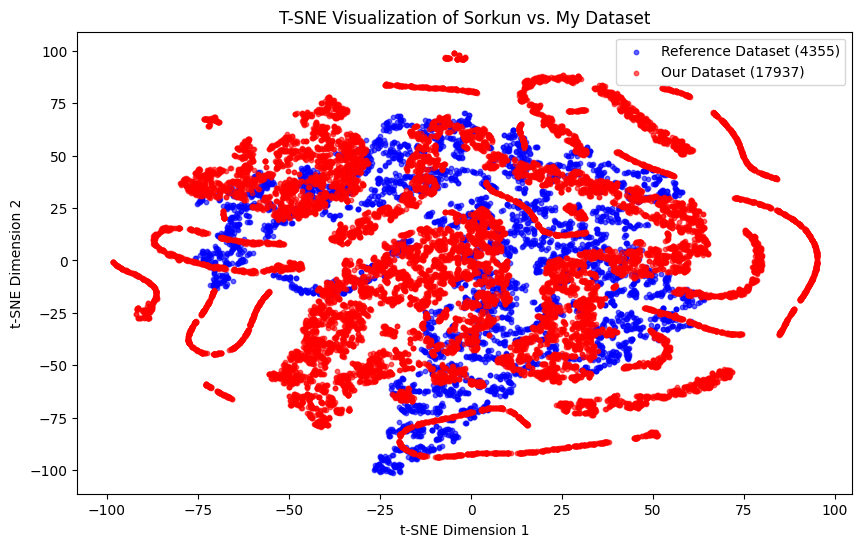

Reference Dataset Convex Hull Area: 16095.48
My Dataset Convex Hull Area: 27614.05
My dataset covers a larger chemical space, indicating better applicability.


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.spatial import ConvexHull

# Function to compute t-SNE embeddings
def compute_tsne(data, perplexity=30, n_components=2, random_state=42):
    tsne = TSNE(n_components=n_components, perplexity=perplexity, random_state=random_state)
    return tsne.fit_transform(data)

# Function to plot and save t-SNE visualization
def plot_tsne(tsne_sorkun, tsne_mydata, save_path="tsne_visualization.png"):
    plt.figure(figsize=(10, 6))
    
    # Scatter plot for Sorkun dataset
    plt.scatter(tsne_sorkun[:, 0], tsne_sorkun[:, 1], label="Reference Dataset (4355)", alpha=0.6, s=10, c='blue')

    # Scatter plot for My dataset
    plt.scatter(tsne_mydata[:, 0], tsne_mydata[:, 1], label="Our Dataset (17937)", alpha=0.6, s=10, c='red')

    plt.legend()
    plt.title("T-SNE Visualization of Sorkun vs. My Dataset")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")

    # Save the figure with 300 DPI
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    # Show the plot
    plt.show()

# Function to calculate convex hull area
def convex_hull_area(data):
    if len(data) < 3:  # Need at least 3 points for a convex hull
        return 0
    hull = ConvexHull(data)
    return hull.volume  # Volume for 2D is the area


# Compute t-SNE embeddings
tsne_sorkun = compute_tsne(training_set_sorkun)
tsne_mydata = compute_tsne(training_set_ABCD)

# Plot and save t-SNE visualization
plot_tsne(tsne_sorkun, tsne_mydata, "tsne_visualization.png")

# Compute convex hull areas
sorkun_area = convex_hull_area(tsne_sorkun)
mydata_area = convex_hull_area(tsne_mydata)

print(f"Reference Dataset Convex Hull Area: {sorkun_area:.2f}")
print(f"My Dataset Convex Hull Area: {mydata_area:.2f}")

# Claim better applicability if our dataset has a larger convex hull
if mydata_area > sorkun_area:
    print("My dataset covers a larger chemical space, indicating better applicability.")
else:
    print("Sorkun dataset has better coverage. Consider adding more diverse compounds.")


In [ ]:
### Need to compare how important to increaese the dataset from (A + B) to (A+B+C) and finalily full dataset (A+B+C+D)

/opt/miniconda3/envs/env2/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/opt/miniconda3/envs/env2/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


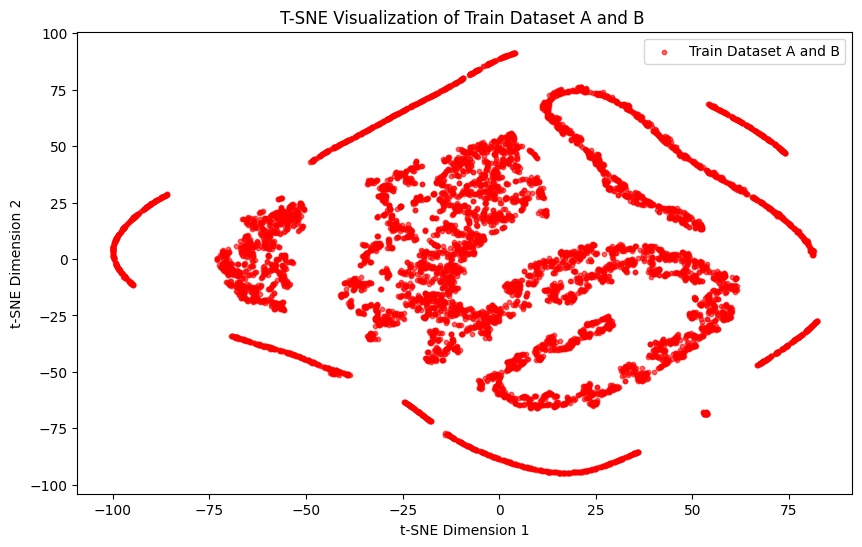

Train Dataset Convex Hull Area: 21974.53


In [11]:
### For combination of data A and B convex hull area 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.spatial import ConvexHull

# Function to compute t-SNE embeddings
def compute_tsne(data, perplexity=30, n_components=2, random_state=42):
    tsne = TSNE(n_components=n_components, perplexity=perplexity, random_state=random_state)
    return tsne.fit_transform(data)

# Function to plot t-SNE visualization
def plot_tsne(tsne_data):
    plt.figure(figsize=(10, 6))
    
    # Scatter plot for the dataset
    plt.scatter(tsne_data[:, 0], tsne_data[:, 1], label="Train Dataset A and B", alpha=0.6, s=10, c='red')
    
    plt.legend()
    plt.title("T-SNE Visualization of Train Dataset A and B ")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.show()

# Function to calculate convex hull area
def convex_hull_area(data):
    if len(data) < 3:  # Need at least 3 points for a convex hull
        return 0
    hull = ConvexHull(data)
    return hull.volume  # Volume for 2D is the area

# Compute t-SNE embeddings
tsne_train_data = compute_tsne(training_set_AB)

# Plot t-SNE visualization
plot_tsne(tsne_train_data)

# Compute convex hull area
train_data_area = convex_hull_area(tsne_train_data)

print(f"Train Dataset Convex Hull Area: {train_data_area:.2f}")


/opt/miniconda3/envs/env2/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/opt/miniconda3/envs/env2/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


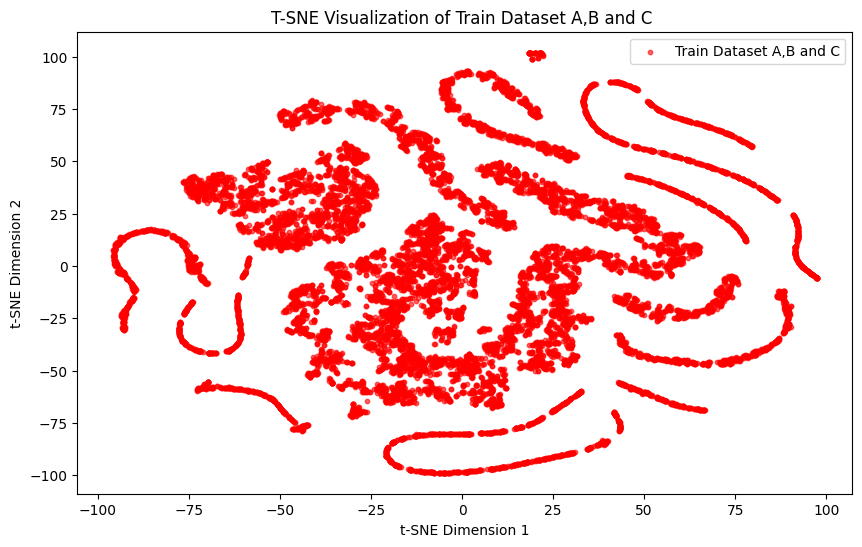

Train Dataset Convex Hull Area for Data A,B and C: 27682.03


In [12]:
### For combination of data AB and C 

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.spatial import ConvexHull

# Function to compute t-SNE embeddings
def compute_tsne(data, perplexity=30, n_components=2, random_state=42):
    tsne = TSNE(n_components=n_components, perplexity=perplexity, random_state=random_state)
    return tsne.fit_transform(data)

# Function to plot t-SNE visualization
def plot_tsne(tsne_data):
    plt.figure(figsize=(10, 6))
    
    # Scatter plot for the dataset
    plt.scatter(tsne_data[:, 0], tsne_data[:, 1], label="Train Dataset A,B and C", alpha=0.6, s=10, c='red')
    
    plt.legend()
    plt.title("T-SNE Visualization of Train Dataset A,B and C ")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.show()

# Function to calculate convex hull area
def convex_hull_area(data):
    if len(data) < 3:  # Need at least 3 points for a convex hull
        return 0
    hull = ConvexHull(data)
    return hull.volume  # Volume for 2D is the area

# Compute t-SNE embeddings
tsne_train_data = compute_tsne(training_set_ABC)

# Plot t-SNE visualization
plot_tsne(tsne_train_data)

# Compute convex hull area
train_data_area = convex_hull_area(tsne_train_data)

print(f"Train Dataset Convex Hull Area for Data A,B and C: {train_data_area:.2f}")


/opt/miniconda3/envs/env2/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/opt/miniconda3/envs/env2/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


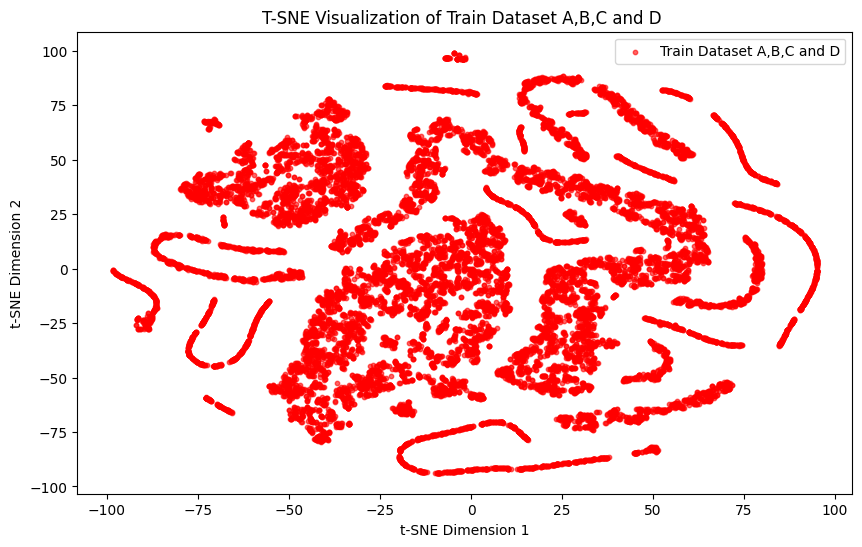

Train Dataset Convex Hull Area for Data A,B,C and D: 27614.05


In [13]:
### Now the all combined data set ABCD  data set 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.spatial import ConvexHull

# Function to compute t-SNE embeddings
def compute_tsne(data, perplexity=30, n_components=2, random_state=42):
    tsne = TSNE(n_components=n_components, perplexity=perplexity, random_state=random_state)
    return tsne.fit_transform(data)

# Function to plot t-SNE visualization
def plot_tsne(tsne_data):
    plt.figure(figsize=(10, 6))
    
    # Scatter plot for the dataset
    plt.scatter(tsne_data[:, 0], tsne_data[:, 1], label="Train Dataset A,B,C and D", alpha=0.6, s=10, c='red')
    
    plt.legend()
    plt.title("T-SNE Visualization of Train Dataset A,B,C and D ")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.show()

# Function to calculate convex hull area
def convex_hull_area(data):
    if len(data) < 3:  # Need at least 3 points for a convex hull
        return 0
    hull = ConvexHull(data)
    return hull.volume  # Volume for 2D is the area

# Compute t-SNE embeddings
tsne_train_data = compute_tsne(training_set_ABCD)

# Plot t-SNE visualization
plot_tsne(tsne_train_data)

# Compute convex hull area
train_data_area = convex_hull_area(tsne_train_data)

print(f"Train Dataset Convex Hull Area for Data A,B,C and D: {train_data_area:.2f}")


In [14]:
print(training_set_AB.shape)
print(training_set_ABC.shape)
print(training_set_ABCD.shape)

(8147, 298)
(15395, 298)
(17937, 298)


/opt/miniconda3/envs/env2/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/opt/miniconda3/envs/env2/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
/opt/miniconda3/envs/env2/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/opt/miniconda3/envs/env2/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
/opt/miniconda3/envs/env2/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/opt/miniconda3/envs/env2/

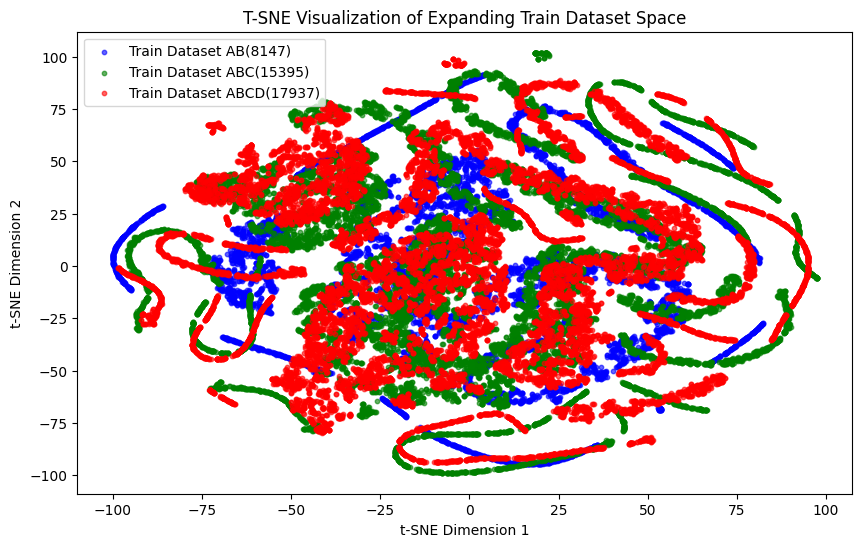

Train Dataset AB Convex Hull Area: 21974.53
Train Dataset ABC Convex Hull Area: 27682.03
Train Dataset ABCD Convex Hull Area: 27614.05


In [15]:
### now visulaizing all together 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.spatial import ConvexHull

# Function to compute t-SNE embeddings

def compute_tsne(data, perplexity=30, n_components=2, random_state=42):
    tsne = TSNE(n_components=n_components, perplexity=perplexity, random_state=random_state)
    return tsne.fit_transform(data)

# Function to plot t-SNE visualization
def plot_tsne(tsne_data_AB, tsne_data_ABC, tsne_data_ABCD):
    plt.figure(figsize=(10, 6))
    
    # Scatter plot for different datasets
    plt.scatter(tsne_data_AB[:, 0], tsne_data_AB[:, 1], label="Train Dataset AB(8147)", alpha=0.6, s=10, c='blue')
    plt.scatter(tsne_data_ABC[:, 0], tsne_data_ABC[:, 1], label="Train Dataset ABC(15395)", alpha=0.6, s=10, c='green')
    plt.scatter(tsne_data_ABCD[:, 0], tsne_data_ABCD[:, 1], label="Train Dataset ABCD(17937)", alpha=0.6, s=10, c='red')
    
    plt.legend()
    plt.title("T-SNE Visualization of Expanding Train Dataset Space")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.show()

# Function to calculate convex hull area
def convex_hull_area(data):
    if len(data) < 3:  # Need at least 3 points for a convex hull
        return 0
    hull = ConvexHull(data)
    return hull.volume  # Volume for 2D is the area

# Compute t-SNE embeddings
tsne_train_data_AB = compute_tsne(training_set_AB)
tsne_train_data_ABC = compute_tsne(training_set_ABC)
tsne_train_data_ABCD = compute_tsne(training_set_ABCD)

# Plot t-SNE visualization
plot_tsne(tsne_train_data_AB, tsne_train_data_ABC, tsne_train_data_ABCD)

# Compute convex hull areas
train_data_area_AB = convex_hull_area(tsne_train_data_AB)
train_data_area_ABC = convex_hull_area(tsne_train_data_ABC)
train_data_area_ABCD = convex_hull_area(tsne_train_data_ABCD)

print(f"Train Dataset AB Convex Hull Area: {train_data_area_AB:.2f}")
print(f"Train Dataset ABC Convex Hull Area: {train_data_area_ABC:.2f}")
print(f"Train Dataset ABCD Convex Hull Area: {train_data_area_ABCD:.2f}")


In [ ]:
### End here